In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True,as_frame=True)
print(X.dtypes)
print()

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

Etape 2 : Vérification des donnés manquantes/nulles et afficher un graphique de distribution pour la variable cible

In [6]:
print(f'There are {pd.concat([X,y], axis=1).isnull().sum().sum()} missinig values')
print()
print(f'Count of Malignant tumors {y.value_counts()[0]}')
print(f'Count of Benign tumors {y.value_counts()[1]}')

There are 0 missinig values

Count of Malignant tumors 212
Count of Benign tumors 357


Etape 3: Utilisation du Heatmap pour visualiser kes valeurs de corrélation

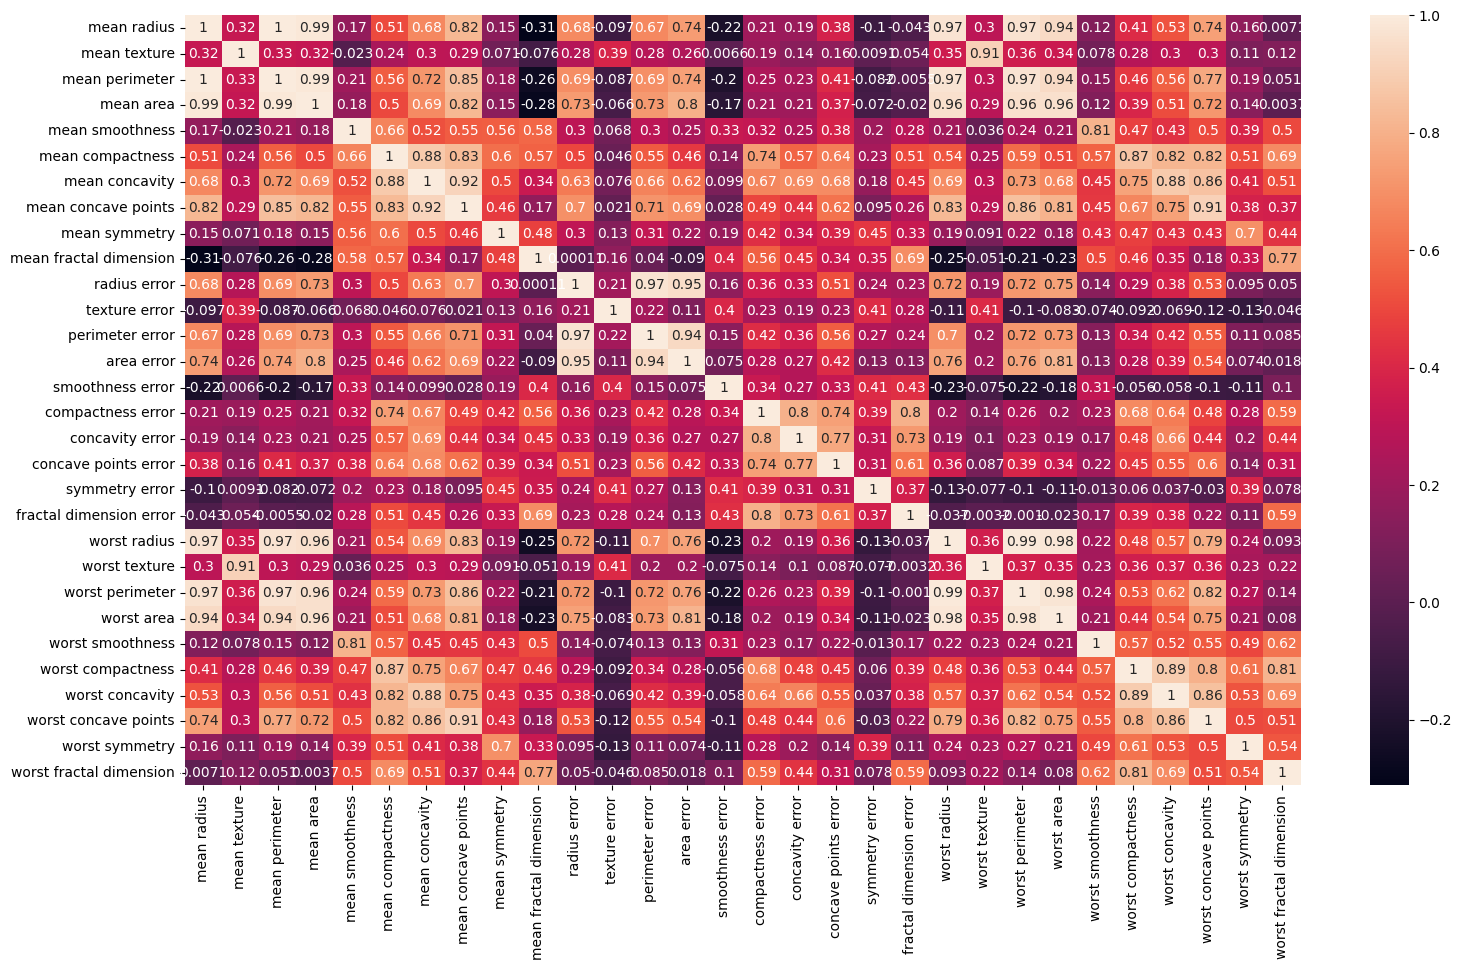

In [7]:
plt.figure(figsize=(18,10))
sns.heatmap(X.corr(),annot = True)
plt.show()

In [8]:
drop_list = ['mean perimeter','mean radius','mean compactness','mean concave points','radius error','perimeter error','compactness error','concave points error','worst radius','worst perimeter','worst compactness','worst concave points','worst texture','worst area']
X = X.drop(drop_list, axis=1)

In [9]:
X

,mean texture,mean area,mean smoothness,mean concavity,mean symmetry,mean fractal dimension,texture error,area error,smoothness error,concavity error,symmetry error,fractal dimension error,worst smoothness,worst concavity,worst symmetry,worst fractal dimension
0,10.38,1001.0,0.11840,0.30010,0.2419,0.07871,0.9053,153.40,0.006399,0.05373,0.03003,0.006193,0.16220,0.7119,0.4601,0.11890
1,17.77,1326.0,0.08474,0.08690,0.1812,0.05667,0.7339,74.08,0.005225,0.01860,0.01389,0.003532,0.12380,0.2416,0.2750,0.08902
2,21.25,1203.0,0.10960,0.19740,0.2069,0.05999,0.7869,94.03,0.006150,0.03832,0.02250,0.004571,0.14440,0.4504,0.3613,0.08758
3,20.38,386.1,0.14250,0.24140,0.2597,0.09744,1.1560,27.23,0.009110,0.05661,0.05963,0.009208,0.20980,0.6869,0.6638,0.17300
4,14.34,1297.0,0.10030,0.19800,0.1809,0.05883,0.7813,94.44,0.011490,0.05688,0.01756,0.005115,0.13740,0.4000,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,22.39,1479.0,0.11100,0.24390,0.1726,0.05623,1.2560,158.70,0.010300,0.05198,0.01114,0.004239,0.14100,0.4107,0.2060,0.07115
565,28.25,1261.0,0.09780,0.14400,0.1752,0.05533,2.4630,99.04,0.005769,0.03950,0.01898,0.002498,0.11660,0.3215,0.2572,0.06637
566,28.08,858.1,0.08455,0.09251,0.1590,0.05648,1.0750,48.55,0.005903,0.04730,0.01318,0.003892,0.11390,0.3403,0.2218,0.07820
567,29.33,1265.0,0.11780,0.35140,0.2397,0.07016,1.5950,86.22,0.006522,0.07117,0.02324,0.006185,0.16500,0.9387,0.4087,0.12400


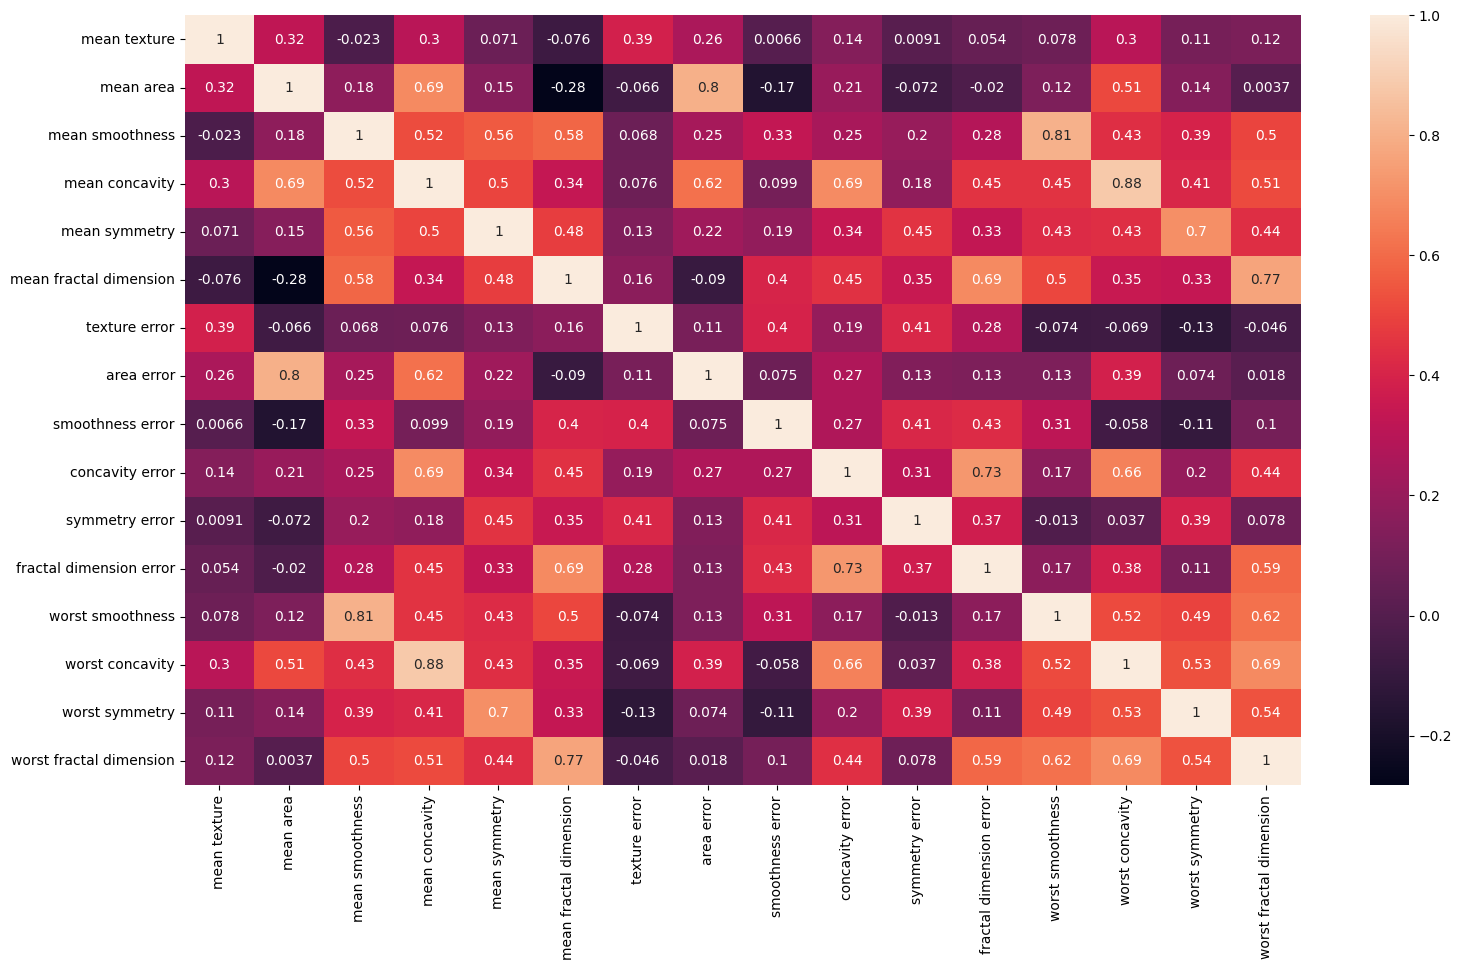

In [10]:
plt.figure(figsize=(18,10))
sns.heatmap(X.corr(),annot = True)
plt.show()

In [15]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Vérifier la distribution initiale des classes
print("Distribution des classes avant SMOTE :", Counter(y))

# Appliquer SMOTE pour équilibrer les classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Vérifier la nouvelle distribution
print("Distribution des classes après SMOTE :", Counter(y_resampled))

# Convertir en DataFrame pour compatibilité avec pandas/seaborn
X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled = pd.Series(y_resampled, name='target')

Distribution des classes avant SMOTE : Counter({1: 357, 0: 212})
Distribution des classes après SMOTE : Counter({0: 357, 1: 357})


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f'The shape of Train data is {X_train.shape}')
print(f'The shape of Test data is {X_test.shape}')

The shape of Train data is (455, 16)
The shape of Test data is (114, 16)


In [14]:
from sklearn.tree import DecisionTreeClassifier
c = DecisionTreeClassifier(criterion='gini', max_depth=10)
dt = c.fit(X_train, y_train)
y_pred = dt.predict(X_test)
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9473684210526315


In [16]:
# Create Decision Tree classifer object
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()

decision_tree = decision_tree.fit(X_train,y_train)

from sklearn.model_selection import GridSearchCV
param_grid = {'criterion' : ['entropy','gini'],
'max_depth' : [2,4,6,8,10,12]}

grid = GridSearchCV(decision_tree, param_grid, cv=5)

grid.fit(X_train, y_train)


print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 10}


In [17]:
from sklearn.tree import DecisionTreeClassifier
c = DecisionTreeClassifier(criterion='entropy', max_depth=8)
dt = c.fit(X_train, y_train)
y_pred = dt.predict(X_test)
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9473684210526315


The accuracy of the model is: 94.74

confusion matrix
[[41  2]
 [ 4 67]]


[Text(0.575, 0.9444444444444444, 'x[1] <= 696.25\nentropy = 0.952\nsamples = 455\nvalue = [169, 286]'),
 Text(0.31, 0.8333333333333334, 'x[13] <= 0.262\nentropy = 0.57\nsamples = 319\nvalue = [43, 276]'),
 Text(0.4425, 0.8888888888888888, 'True  '),
 Text(0.12, 0.7222222222222222, 'x[10] <= 0.016\nentropy = 0.099\nsamples = 234\nvalue = [3, 231]'),
 Text(0.08, 0.6111111111111112, 'x[0] <= 18.085\nentropy = 0.255\nsamples = 70\nvalue = [3, 67]'),
 Text(0.04, 0.5, 'entropy = 0.0\nsamples = 48\nvalue = [0, 48]'),
 Text(0.12, 0.5, 'x[10] <= 0.016\nentropy = 0.575\nsamples = 22\nvalue = [3, 19]'),
 Text(0.08, 0.3888888888888889, 'x[0] <= 18.155\nentropy = 0.454\nsamples = 21\nvalue = [2, 19]'),
 Text(0.04, 0.2777777777777778, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.12, 0.2777777777777778, 'x[14] <= 0.299\nentropy = 0.286\nsamples = 20\nvalue = [1, 19]'),
 Text(0.08, 0.16666666666666666, 'entropy = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.16, 0.16666666666666666, 'x[12] <

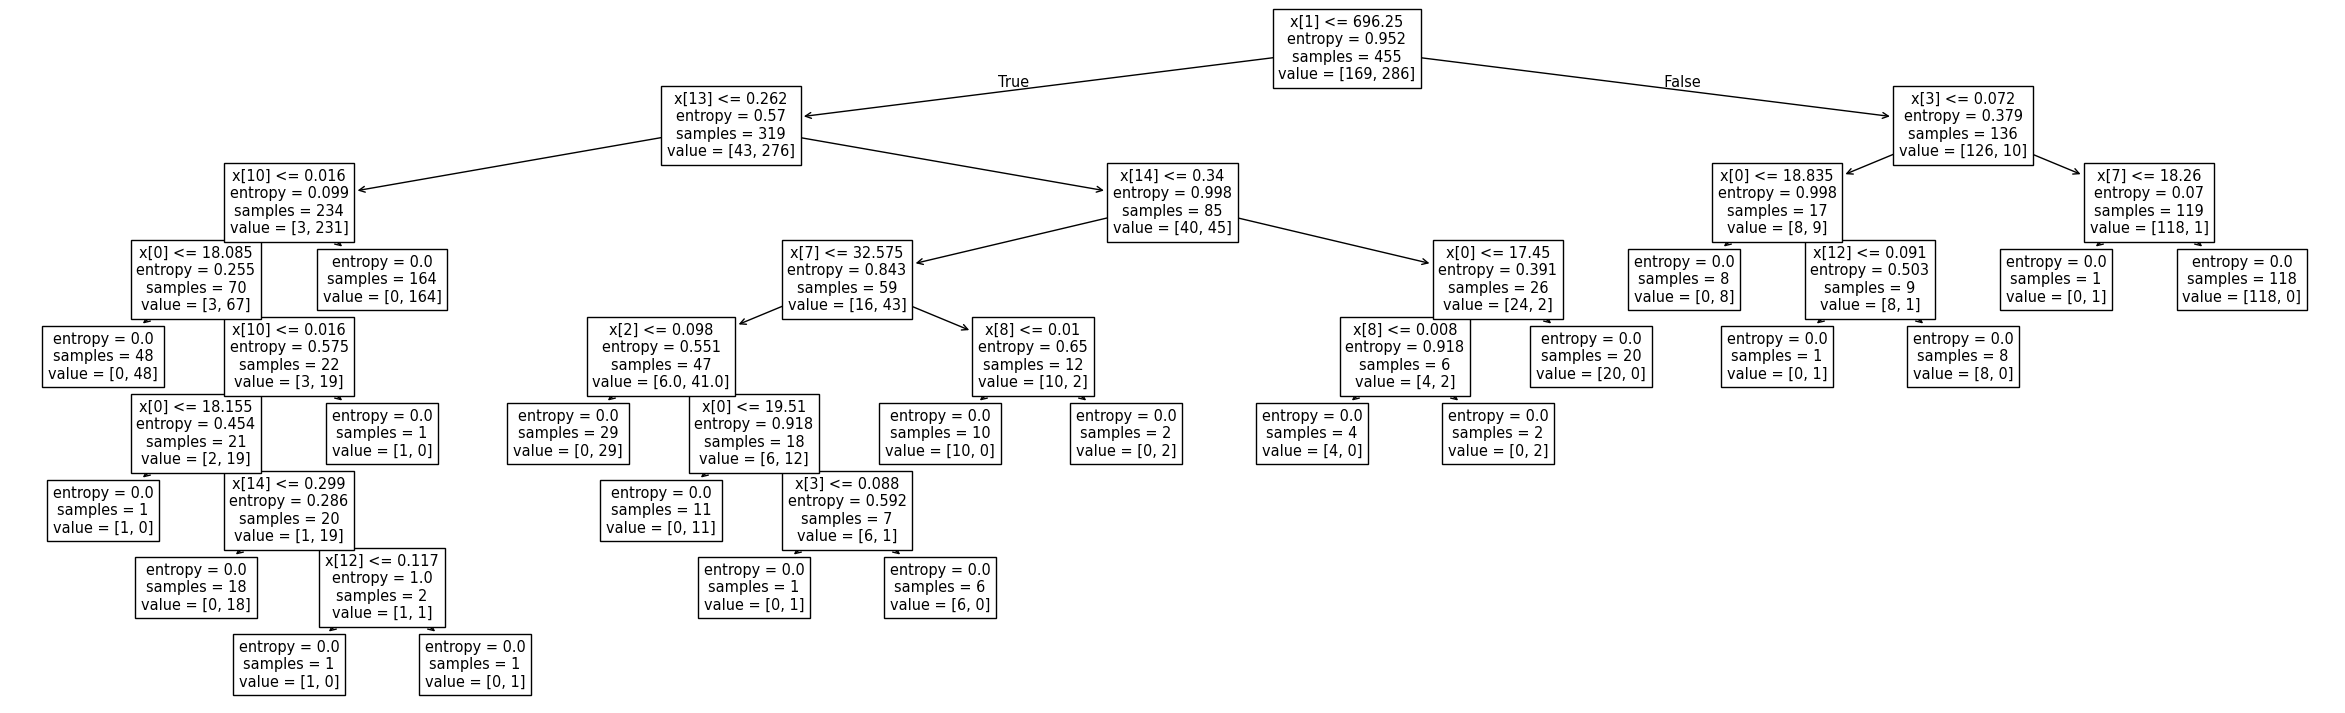

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score
print(f'The accuracy of the model is: {accuracy_score(y_test,y_pred)*100:0.2f}')
print()
print('confusion matrix')
print(f'{confusion_matrix(y_test, y_pred)}')

import matplotlib.pyplot as plt
plt.figure(figsize=(30,9))
from sklearn import tree
tree.plot_tree(dt)